In [15]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [16]:

class TFRecordDataHandler:
    def __init__(self, tfrecord_file, batch_size=32, shuffle=True, augment=False):
        self.tfrecord_file = tfrecord_file
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.dataset = self._load_dataset()
        self.length = self.__len__()

    def _parse_function(self, proto):
        # Definir la descripción de las características
        feature_description = {
            'image': tf.io.FixedLenFeature([], tf.string),
            'height': tf.io.FixedLenFeature([], tf.int64),
            'width': tf.io.FixedLenFeature([], tf.int64),
            'mask': tf.io.FixedLenFeature([], tf.string),
            'mask_height': tf.io.FixedLenFeature([], tf.int64),
            'mask_width': tf.io.FixedLenFeature([], tf.int64),
            'group_name': tf.io.FixedLenFeature([], tf.int64),
            'mouse_id': tf.io.FixedLenFeature([], tf.int64),
            'day_of_study': tf.io.FixedLenFeature([], tf.int64),
        }
        parsed_features = tf.io.parse_single_example(proto, feature_description)
        
        # Decodificar la imagen
        image = tf.io.decode_raw(parsed_features['image'], tf.uint8)
        image = tf.reshape(image, [parsed_features['height'], parsed_features['width'], 3])

        # Decodificar la máscara
        mask = tf.io.decode_raw(parsed_features['mask'], tf.uint8)
        mask = tf.reshape(mask, [parsed_features['mask_height'], parsed_features['mask_width'], 1])

        # Combine image and mask into a single tensor
        image = tf.concat([image, mask], axis=-1)
        
        # return image, mask, parsed_features['group_name'], parsed_features['mouse_id'], parsed_features['day_of_study']
        return image, parsed_features['group_name']

    def _normalize(self, image, mask, group_name, mouse_id, day_of_study):
        # Convertir la imagen a float y normalizarla al rango [0, 1]
        image = tf.cast(image, tf.float32) / 255.0
        # Convertir la máscara a float y normalizarla al rango [0, 1]
        mask = tf.cast(mask, tf.float32) / 255.0

        #return image, mask, group_name, mouse_id, day_of_study
        return image, group_name

    def _augment(self, image, mask, group_name, mouse_id, day_of_study):
        # Aumentación: flipping horizontal y brillo aleatorio
        if tf.random.uniform(()) > 0.5:
            image = tf.image.flip_left_right(image)
            mask = tf.image.flip_left_right(mask)
        image = tf.image.random_brightness(image, max_delta=0.1)

        #return image, mask, group_name, mouse_id, day_of_study
        return image, group_name

    def _load_dataset(self):
        # Cargar el archivo TFRecord y aplicar los mapeos
        dataset = tf.data.TFRecordDataset(self.tfrecord_file)
        dataset = dataset.map(self._parse_function, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.map(self._normalize, num_parallel_calls=tf.data.AUTOTUNE)

        if self.augment:
            dataset = dataset.map(self._augment, num_parallel_calls=tf.data.AUTOTUNE)

        if self.shuffle:
            dataset = dataset.shuffle(buffer_size=1000)

        # Aplicar batch y prefetch para eficiencia
        dataset = dataset.batch(self.batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        
        return dataset
    
    def __len__(self):
        size = sum(1 for _ in tf.data.TFRecordDataset(self.tfrecord_file))
        return int(np.ceil(size / self.batch_size))


In [17]:

def visualize_data(image_batch, mask_batch, group_name_batch, mouse_id_batch, day_of_study_batch, num_samples=5):
    num_samples = min(num_samples, image_batch.shape[0]) # Asegurar que no se muestren más muestras de las disponibles
    plt.figure(figsize=(15, num_samples * 5))  # Ajustar tamaño para una mejor visualización
    for i in range(num_samples):
        # Mostrar imagen
        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.imshow(np.clip(image_batch[i], 0, 1))  # Asegurar que los valores de la imagen están en [0, 1]
        plt.title(f"Group: {group_name_batch[i]}, Mouse ID: {mouse_id_batch[i]}, Day: {day_of_study_batch[i]}")
        plt.axis('off')

        # Mostrar máscara
        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.imshow(mask_batch[i], cmap='gray')
        plt.title("Mask")
        plt.axis('off')

        # Superponer imagen y máscara
        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.imshow(np.clip(image_batch[i], 0, 1))  # Mostrar imagen normalizada
        plt.imshow(mask_batch[i], cmap='jet', alpha=0.5)  # Superponer la máscara con transparencia
        plt.title("Image + Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [18]:
# Create the data handler
train_tfrefcord = 'train.tfrecords'
train_ds = TFRecordDataHandler(train_tfrefcord, batch_size=4, shuffle=True, augment=True)

images_tf, masks_tf, group_name_batches, mouse_id_batches, day_of_study_batches = next(iter(train_ds.dataset))

visualize_data(images_tf, masks_tf, group_name_batches, mouse_id_batches, day_of_study_batches, num_samples=4)


TypeError: in user code:


    TypeError: outer_factory.<locals>.inner_factory.<locals>.tf___normalize() missing 3 required positional arguments: 'group_name', 'mouse_id', and 'day_of_study'


In [12]:
# Dataset size
print("Train dataset size:", train_ds.length)

Train dataset size: 67


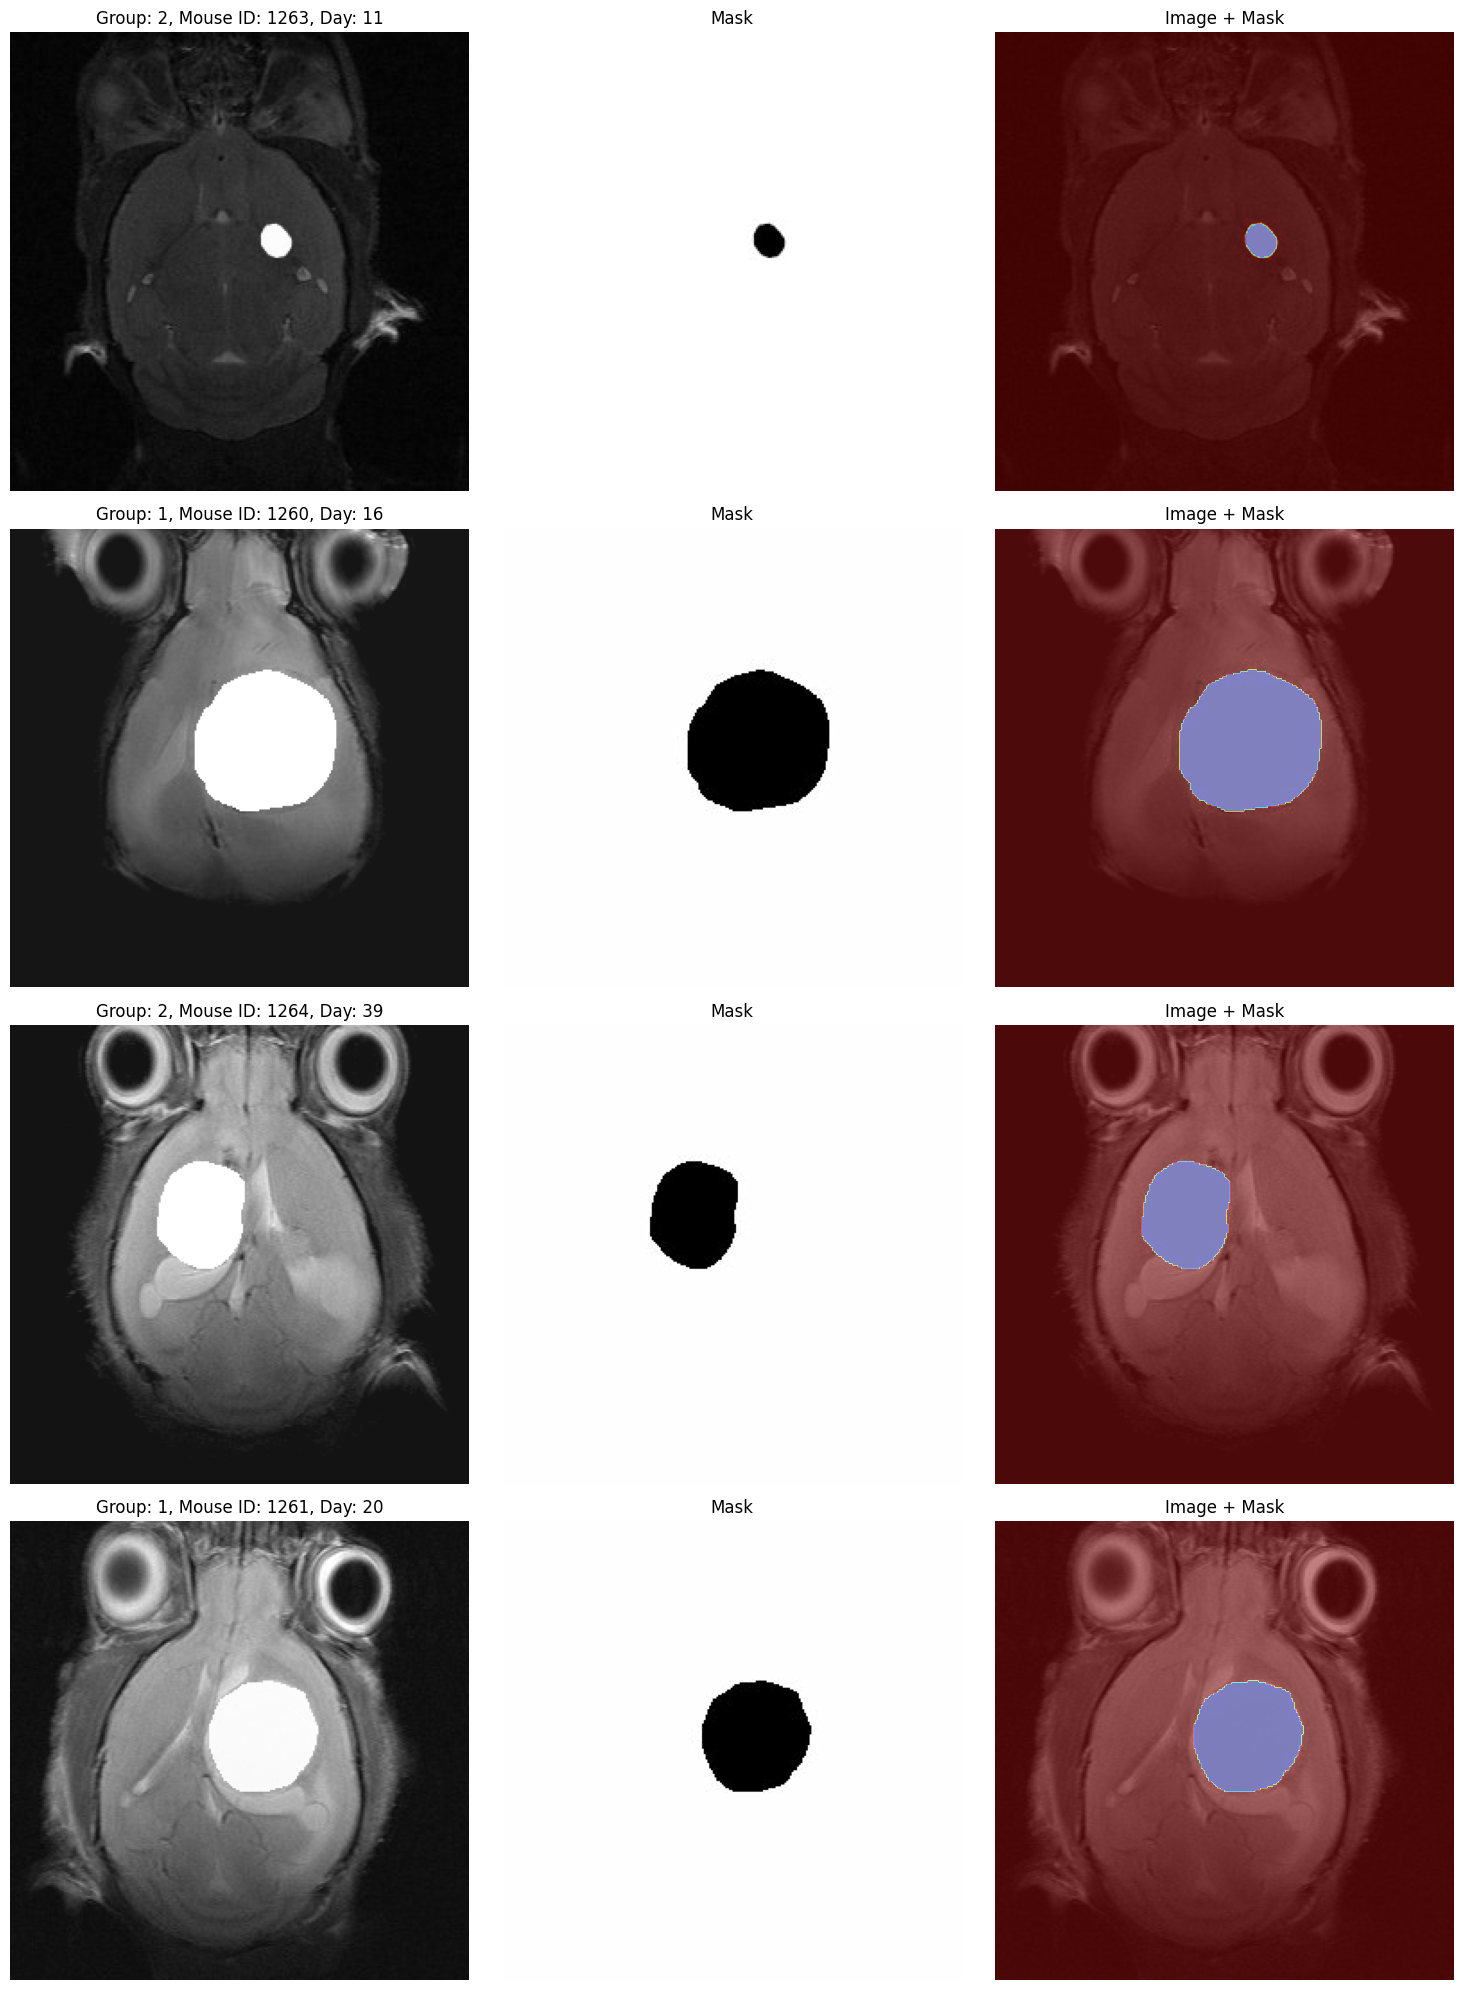

In [13]:
# Create the validation data handler
val_tfrefcord = 'val.tfrecords'
val_ds = TFRecordDataHandler(val_tfrefcord, batch_size=4, shuffle=True, augment=True)

images_tf, masks_tf, group_name_batches, mouse_id_batches, day_of_study_batches = next(iter(val_ds.dataset))

visualize_data(images_tf, masks_tf, group_name_batches, mouse_id_batches, day_of_study_batches, num_samples=4)


In [ ]:
from keras_unet_collection import models
from keras import layers
import tensorflow as tf

# Definir el modelo U-Net 2D con ResNet34 como backbone
model = models.unet_2d(
    input_size=(256, 256, 3),              # Tamaño de las imágenes de entrada
    filter_num=[64, 128, 256, 512, 1024],  # Número de filtros en cada bloque
    n_labels=3,                            # 3 clases (control, recayente, curado)
    stack_num_down=2, stack_num_up=1,      # Número de bloques en cada etapa de downsampling/upsampling
    activation='GELU',                     # Activación de las capas
    output_activation='Softmax',           # Softmax para clasificación multiclase
    batch_norm=True,                       # Usar batch normalization
    pool='max', unpool=False,              # Max pooling y sin unpooling
    name='unet'
)

# Compilar el modelo con categorical_crossentropy y optimizador adecuado
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Mostrar la estructura del modelo
model.summary()

# Entrenar el modelo
model.fit(train_ds.dataset, epochs=5, validation_data=val_ds.dataset)


In [14]:
# from keras_unet_collection import models
# from keras import layers

# # Definir el modelo U-Net 2D con ResNet34 como backbone
# model = models.unet_2d(
#     input_size=(256, 256, 3),          # Tamaño de las imágenes de entrada
#     filter_num=[64, 128, 256, 512, 1024],  # Número de filtros en cada bloque
#     n_labels=1,                        # 2 clqawses
#     stack_num_down=2, stack_num_up=1,   # Número de bloques en cada etapa de downsampling/upsampling
#     activation='GELU',                  # Activación de las capas
#     output_activation='Sigmoid',        # Sigmoid para salida binaria
#     batch_norm=True,                    # Usar batch normalization
#     pool='max', unpool=False,           # Max pooling y sin unpooling
#     name='unet'
# )

# # Compilar el modelo con binary_crossentropy y un optimizador adecuado
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Mostrar la estructura del modelo
# model.summary()

# # Entrenar el modelo (asegúrate de que `train_dataset` y `val_dataset` estén definidos)
# # El dataset debe ser un `tf.data.Dataset` con imágenes y etiquetas binarios
# # Asegúrate de que `train_dataset` esté configurado con imágenes y etiquetas como salida.

# # Definir datasets de ejemplo (asegúrate de usar tu propio dataset aquí)
# # train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).batch(16)

# # Entrenar el modelo con el dataset
# model.fit(train_ds.dataset, epochs=5, validation_data=val_ds.dataset)


Model: "unet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0        │ (None, 256, 256,  │      1,728 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0_bn     │ (None, 256, 256,  │        256 │ unet_down0_0[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_0_activ… │ (None, 256, 256,  │          0 │ unet_down0_0_bn[… │
│ (GELU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1        │ (None, 256, 256,  │     36,864 │ unet_down0_0_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1_bn     │ (None, 256, 256,  │        256 │ unet_down0_1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down0_1_activ… │ (None, 256, 256,  │          0 │ unet_down0_1_bn[… │
│ (GELU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_encode_… │ (None, 128, 128,  │          0 │ unet_down0_1_act… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0   │ (None, 128, 128,  │     73,728 │ unet_down1_encod… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0_… │ (None, 128, 128,  │        512 │ unet_down1_conv_… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_0_… │ (None, 128, 128,  │          0 │ unet_down1_conv_… │
│ (GELU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1   │ (None, 128, 128,  │    147,456 │ unet_down1_conv_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1_… │ (None, 128, 128,  │        512 │ unet_down1_conv_… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv_1_… │ (None, 128, 128,  │          0 │ unet_down1_conv_… │
│ (GELU)              │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_encode_… │ (None, 64, 64,    │          0 │ unet_down1_conv_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0   │ (None, 64, 64,    │    294,912 │ unet_down2_encod… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv_0_… │ (None, 64, 64,    │      1,024 │ unet_down2_conv_

 Total params: 34,534,849 (131.74 MB)

 Trainable params: 34,521,153 (131.69 MB)

 Non-trainable params: 13,696 (53.50 KB)

Epoch 1/5


ValueError: Data is expected to be in format `x`, `(x,)`, `(x, y)`, or `(x, y, sample_weight)`, found: (<tf.Tensor 'data:0' shape=(None, None, None, 4) dtype=float32>, <tf.Tensor 'data_1:0' shape=(None, None, None, 1) dtype=float32>, <tf.Tensor 'data_2:0' shape=(None,) dtype=int64>, <tf.Tensor 'data_3:0' shape=(None,) dtype=int64>, <tf.Tensor 'data_4:0' shape=(None,) dtype=int64>)

In [ ]:
"""def train_model_cv(model, X_train, y_train, X_val, y_val, X_test, y_test):
    y_train = y_train.values.ravel()
    y_val = y_val.values.ravel()
    y_test = y_test.values.ravel()

    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', verbose=0)
    print("CV Scores:", cv_score)

    acc_mean = cv_score.mean()
    acc_std = cv_score.std()
    print(f"CV Score: {acc_mean:.4f}+-{acc_std:.4f}")

    # Train Model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred)
    print("Validation Accuracy:", acc_val)

    # Predict
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    print("Test Accuracy:", acc_test)
    return model, acc_mean, acc_val, acc_test"""